In [4]:
from google.colab import files
uploaded = files.upload()

Saving SuperStore_Sales_Dataset.csv to SuperStore_Sales_Dataset.csv


In [5]:
import pandas as pd

df = pd.read_csv('SuperStore_Sales_Dataset.csv')
df.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,01-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,03-01-2019,05-01-2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN
4,8604,US-2019-116365,03-01-2019,08-01-2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN


In [6]:
#exploracion inicial
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  5901 non-null   int64  
 1   Order ID          5901 non-null   object 
 2   Order Date        5901 non-null   object 
 3   Ship Date         5901 non-null   object 
 4   Ship Mode         5901 non-null   object 
 5   Customer ID       5901 non-null   object 
 6   Customer Name     5901 non-null   object 
 7   Segment           5901 non-null   object 
 8   Country           5901 non-null   object 
 9   City              5901 non-null   object 
 10  State             5901 non-null   object 
 11  Region            5901 non-null   object 
 12  Product ID        5901 non-null   object 
 13  Category          5901 non-null   object 
 14  Sub-Category      5901 non-null   object 
 15  Product Name      5901 non-null   object 
 16  Sales             5901 non-null   float64


,0
Row ID+O6G3A1:R6,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [8]:
df.columns

Index(['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'ind1',
       'ind2'],
      dtype='object')

In [9]:
df.columns = df.columns.str.strip()

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [12]:
df['Order Date'].head()

,Order Date
0,2019-01-01
1,2019-01-02
2,2019-01-02
3,2019-01-03
4,2019-01-03


<Axes: title={'center': 'Ventas por categoría'}, xlabel='Category'>

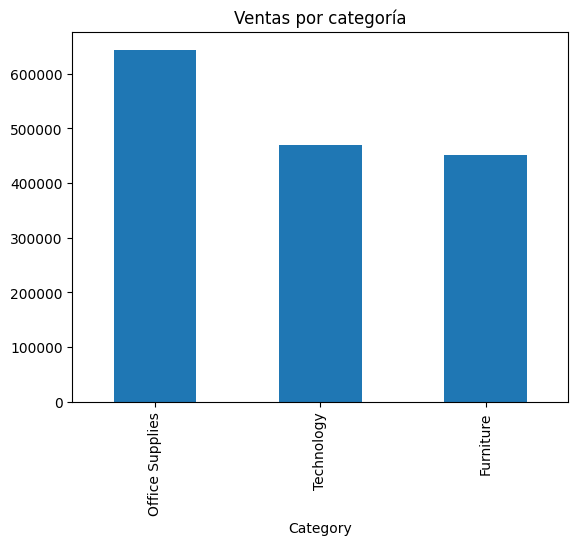

In [13]:
sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

sales_category.plot(kind='bar', title='Ventas por categoría')

<Axes: title={'center': 'Ventas por región'}, xlabel='Region'>

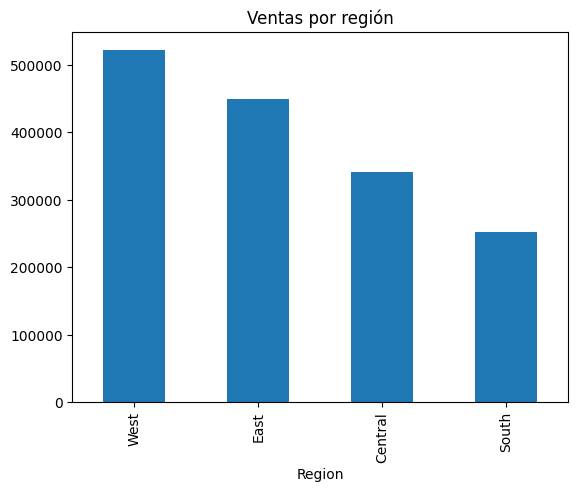

In [14]:
sales_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

sales_region.plot(kind='bar', title='Ventas por región')

<Axes: title={'center': 'Relación Ventas vs Ganancia'}, xlabel='Sales', ylabel='Profit'>

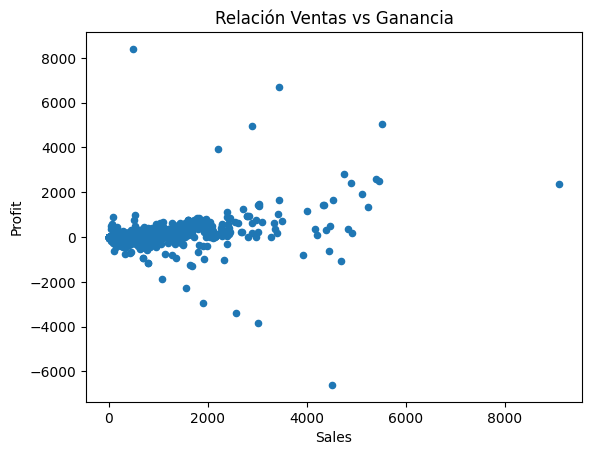

In [15]:
df.plot.scatter(x='Sales', y='Profit', title='Relación Ventas vs Ganancia')

<Axes: title={'center': 'Ventas en el tiempo'}, xlabel='Order Date'>

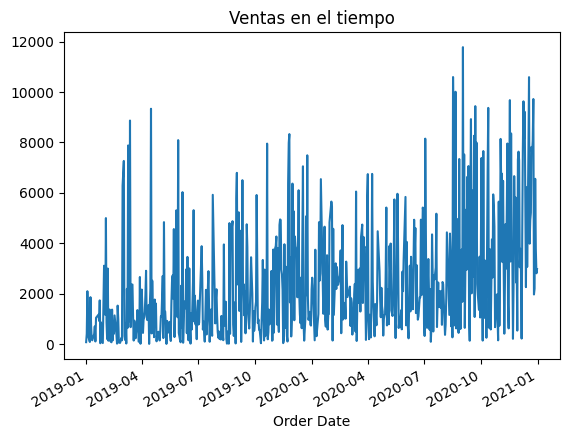

In [16]:
sales_time = df.groupby('Order Date')['Sales'].sum()

sales_time.plot(title='Ventas en el tiempo')

In [17]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
3D Systems Cube Printer, 2nd Generation, Magenta                               14334.890
Canon imageCLASS 2200 Advanced Copier                                          14076.824
Hewlett Packard LaserJet 3310 Copier                                           13837.732
GBC DocuBind TL300 Electric Binding System                                     12890.258
GBC DocuBind P400 Electric Binding System                                      12577.108
Samsung Galaxy Mega 6.3                                                        12370.708
Martin Yale Chadless Opener Electric Letter Opener                             12268.902
HON 5400 Series Task Chairs for Big and Tall                                   11887.562
Global Troy Executive Leather Low-Back Tilter                                  10217.894
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     9756.524
Name: Sales, dtype: float64


# 1. Carga de datos
# 2. Exploración inicial
# 3. Limpieza de datos
# 4. Análisis exploratorio (EDA)
# 5. Insights de negocio
## Insights

- La categoría con mayor volumen de ventas es office supplies, lo que indica una fuerte demanda en este segmento.
- La región west lidera en ingresos, sugiriendo oportunidades de expansión.
- Se identifican casos donde altas ventas no implican alta rentabilidad, lo cual requiere revisión de costos.
- Existen patrones temporales en las ventas que podrían aprovecharse estratégicamente.
